In [1]:
import random
from pathlib import Path
import yaml
import numpy as np
import torch
from huggingface_hub import hf_hub_download, snapshot_download

from PrithviWxC.dataloaders.merra2 import (
    Merra2Dataset,
    preproc,
    input_scalers,
    output_scalers,
    static_input_scalers,
)
from PrithviWxC.model import PrithviWxC
print('1')
# ==========================================
# 1. Environment & Device Setup
# ==========================================
torch.jit.enable_onednn_fusion(True)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True
    torch.cuda.manual_seed(42)
else:
    device = torch.device("cpu")

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

print(f"Using device: {device}")

print('2')

# ==========================================
# 2. Variable Definitions & Task Config
# ==========================================
surface_vars = [
    "EFLUX", "GWETROOT", "HFLUX", "LAI", "LWGAB", "LWGEM", "LWTUP",
    "PS", "QV2M", "SLP", "SWGNT", "SWTNT", "T2M", "TQI", "TQL",
    "TQV", "TS", "U10M", "V10M", "Z0M"
]
static_surface_vars = ["FRACI", "FRLAND", "FROCEAN", "PHIS"]
vertical_vars = ["CLOUD", "H", "OMEGA", "PL", "QI", "QL", "QV", "T", "U", "V"]
levels = [34.0, 39.0, 41.0, 43.0, 44.0, 45.0, 48.0, 51.0, 53.0, 56.0, 63.0, 68.0, 71.0, 72.0]

padding = {"level": [0, 0], "lat": [0, -1], "lon": [0, 0]}
lead_times = [18]
input_times = [-6]
time_range = ("2020-01-01T00:00:00", "2020-01-02T05:59:59")
positional_encoding = "fourier"

variable_names = surface_vars + [
    f"{var}_level_{level}" for var in vertical_vars for level in levels
]

print('3')
# ==========================================
# 3. Data Directories & Downloads
# ==========================================
data_dir = Path("../data")
surf_dir = data_dir / "merra-2"
vert_dir = data_dir / "merra-2"
surf_clim_dir = data_dir / "climatology"
vert_clim_dir = data_dir / "climatology"

# Download required MERRA-2 and Climatology data from HuggingFace
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="merra-2/MERRA2_sfc_2020010[1].nc",
    local_dir=str(data_dir),
)
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="merra-2/MERRA_pres_2020010[1].nc",
    local_dir=str(data_dir),
)
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="climatology/climate_surface_doy00[1]*.nc",
    local_dir=str(data_dir),
)
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="climatology/climate_vertical_doy00[1]*.nc",
    local_dir=str(data_dir),
)
print('4')
# ==========================================
# 4. Dataset Instantiation
# ==========================================
dataset = Merra2Dataset(
    time_range=time_range,
    lead_times=lead_times,
    input_times=input_times,
    data_path_surface=surf_dir,
    data_path_vertical=vert_dir,
    climatology_path_surface=surf_clim_dir,
    climatology_path_vertical=vert_clim_dir,
    surface_vars=surface_vars,
    static_surface_vars=static_surface_vars,
    vertical_vars=vertical_vars,
    levels=levels,
    positional_encoding=positional_encoding,
)
assert len(dataset) > 0, "There doesn't seem to be any valid data."

print('5')
# ==========================================
# 5. Load Scalers
# ==========================================
surf_in_scal_path = data_dir / "climatology/musigma_surface.nc"
vert_in_scal_path = data_dir / "climatology/musigma_vertical.nc"
surf_out_scal_path = data_dir / "climatology/anomaly_variance_surface.nc"
vert_out_scal_path = data_dir / "climatology/anomaly_variance_vertical.nc"

hf_hub_download(repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M", filename=f"climatology/{surf_in_scal_path.name}", local_dir=str(data_dir))
hf_hub_download(repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M", filename=f"climatology/{vert_in_scal_path.name}", local_dir=str(data_dir))
hf_hub_download(repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M", filename=f"climatology/{surf_out_scal_path.name}", local_dir=str(data_dir))
hf_hub_download(repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M", filename=f"climatology/{vert_out_scal_path.name}", local_dir=str(data_dir))

in_mu, in_sig = input_scalers(surface_vars, vertical_vars, levels, surf_in_scal_path, vert_in_scal_path)
output_sig = output_scalers(surface_vars, vertical_vars, levels, surf_out_scal_path, vert_out_scal_path)
static_mu, static_sig = static_input_scalers(surf_in_scal_path, static_surface_vars)

print('6')
# ==========================================
# 6. Model Construction & Configuration
# ==========================================
hf_hub_download(repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M", filename="config.yaml", local_dir=str(data_dir))

with open(data_dir / "config.yaml", "r") as f:
    config = yaml.safe_load(f)

model = PrithviWxC(
    in_channels=config["params"]["in_channels"],
    input_size_time=config["params"]["input_size_time"],
    in_channels_static=config["params"]["in_channels_static"],
    input_scalers_mu=in_mu,
    input_scalers_sigma=in_sig,
    input_scalers_epsilon=config["params"]["input_scalers_epsilon"],
    static_input_scalers_mu=static_mu,
    static_input_scalers_sigma=static_sig,
    static_input_scalers_epsilon=config["params"]["static_input_scalers_epsilon"],
    output_scalers=output_sig**0.5,
    n_lats_px=config["params"]["n_lats_px"],
    n_lons_px=config["params"]["n_lons_px"],
    patch_size_px=config["params"]["patch_size_px"],
    mask_unit_size_px=config["params"]["mask_unit_size_px"],
    mask_ratio_inputs=0.0,
    mask_ratio_targets=0.0,
    embed_dim=config["params"]["embed_dim"],
    n_blocks_encoder=config["params"]["n_blocks_encoder"],
    n_blocks_decoder=config["params"]["n_blocks_decoder"],
    mlp_multiplier=config["params"]["mlp_multiplier"],
    n_heads=config["params"]["n_heads"],
    dropout=config["params"]["dropout"],
    drop_path=config["params"]["drop_path"],
    parameter_dropout=config["params"]["parameter_dropout"],
    residual="climate",
    masking_mode="global",
    encoder_shifting=True,
    decoder_shifting=True,
    positional_encoding=positional_encoding,
    checkpoint_encoder=[],
    checkpoint_decoder=[],
)
print('7')
# ==========================================
# 7. Load Weights
# ==========================================
weights_path = data_dir / "weights/prithvi.wxc.2300m.v1.pt"

state_dict = torch.load(weights_path, map_location="cpu", weights_only=False)
if "model_state" in state_dict:
    state_dict = state_dict["model_state"]

model.load_state_dict(state_dict, strict=True)
model = model.to(device)
print('8')
# ==========================================
# 8. Batch Preprocessing & Inference
# ==========================================
data = next(iter(dataset))
batch = preproc([data], padding)

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

with torch.no_grad():
    model.eval()
    out = model(batch)

print(f"Inference complete! Output tensor shape: {out.shape}")

1
Using device: cuda
2
3


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

4
5
6
7
8


/home/gpuuser7/gpuuser7_a/miniconda3/envs/alok/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Inference complete! Output tensor shape: torch.Size([1, 160, 360, 576])


# encoder blocks similarity all 12 and all 13 blocks

/home/gpuuser7/gpuuser7_a/miniconda3/envs/alok/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Processed 2 samples. Averaging similarity matrix...


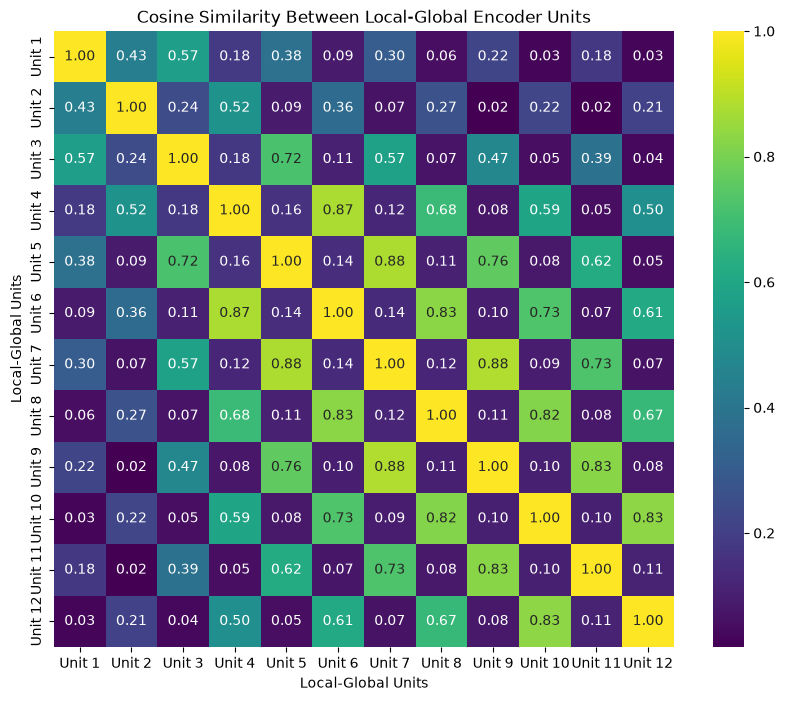

--- Pruning Candidates (Similarity Threshold: 0.85) ---
Indices of Units to prune (0-indexed): [5, 6]
Original Encoder Layers to prune: [10, 11, 12, 13]
Note: Pruning has NOT been executed. The original model configuration remains intact.


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from torch.nn.functional import cosine_similarity

# ==========================================
# 9. Extract Hidden States via Hooks
# ==========================================
# Locate the 25 encoder layers dynamically. 
# They are typically wrapped in a nn.ModuleList within the model.
encoder_blocks = None
for name, module in model.named_modules():
    if isinstance(module, torch.nn.ModuleList) and len(module) == 25:
        encoder_blocks = module
        break

if encoder_blocks is None:
    # Fallback to standard naming conventions if the dynamic search fails
    encoder_blocks = model.blocks if hasattr(model, "blocks") else model.encoder 

unit_outputs = []

def get_activation():
    """Hook to capture the output of a specific layer."""
    def hook(module, input, output):
        # Depending on the architecture, blocks may return a tuple or a tensor
        if isinstance(output, tuple):
            unit_outputs.append(output[0].detach())
        else:
            unit_outputs.append(output.detach())
    return hook

handles = []
# The 12 units correspond to (Local, Global) pairs. 
# The output of each unit is simply the output of its Global attention layer.
# These exist at odd indices: 1, 3, 5, ..., 23. Layer 24 (the final local layer) is excluded.
for i in range(1, 24, 2):
    handles.append(encoder_blocks[i].register_forward_hook(get_activation()))

# ==========================================
# 10. Calculate Similarity Matrix for 12 Units
# ==========================================
dataset_similarity_matrix = torch.zeros((12, 12)).to(device)
cnt = 0

model.eval()

# Process the dataset to get average cosine similarities
for data in dataset:
    unit_outputs.clear() # Reset for the new sample
    
    # Preprocess the data sample
    batch = preproc([data], padding)
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to(device)
            
    with torch.no_grad():
        out = model(batch)
        
    # unit_outputs contains 12 tensors representing the 12 units. Stack them:
    # Shape becomes: [12, batch_size=1, seq_len, embed_dim]
    hidden_states = torch.stack(unit_outputs)
    
    # Flatten spatial/sequence dimensions to guarantee a [12, total_tokens, embed_dim] shape
    decoder_hidden_states = hidden_states.view(12, -1, hidden_states.shape[-1])
        
    similarity_matrix = torch.zeros((12, 12)).to(device)
    
    for layer_i in range(12):
        for layer_j in range(layer_i, 12):
            # Vectorized computation of cosine similarity is mathematically identical 
            # to the sequence loop method but exponentially faster.
            sim = cosine_similarity(
                decoder_hidden_states[layer_i],
                decoder_hidden_states[layer_j],
                dim=-1
            )
            # Average similarity across all tokens for this specific pair
            avg_similarity = sim.mean().item()
            
            similarity_matrix[layer_i, layer_j] = avg_similarity
            similarity_matrix[layer_j, layer_i] = avg_similarity
            
    dataset_similarity_matrix += similarity_matrix
    cnt += 1

# Average over all processed samples
print(f"Processed {cnt} samples. Averaging similarity matrix...")
dataset_similarity_matrix /= cnt

# Clean up hooks to free memory
for handle in handles:
    handle.remove()

# ==========================================
# 11. Visualize Similarity Heatmap
# ==========================================
sim_matrix_np = dataset_similarity_matrix.cpu().numpy()

plt.figure(figsize=(10, 8))
unit_labels = [f"Unit {i+1}" for i in range(12)]

sns.heatmap(
    sim_matrix_np, 
    annot=True, 
    fmt=".2f", 
    cmap="viridis",
    xticklabels=unit_labels, 
    yticklabels=unit_labels
)

plt.title("Cosine Similarity Between Local-Global Encoder Units")
plt.xlabel("Local-Global Units")
plt.ylabel("Local-Global Units")
plt.show()

# ==========================================
# 12. Determine Units to Prune (Threshold = 0.85)
# ==========================================
thres = 0.85
ind_unit_to_del = set()

# Iteratively check and mark redundant units for deletion
for i in range(len(sim_matrix_np)):
    if i in ind_unit_to_del:
        continue
    for k in range(i + 1, len(sim_matrix_np)):
        if k in ind_unit_to_del:
            continue
        # If similarity surpasses the threshold, flag 'k' for deletion
        if sim_matrix_np[i][k] >= thres:
            ind_unit_to_del.add(k)

print(f"--- Pruning Candidates (Similarity Threshold: {thres}) ---")
print("Indices of Units to prune (0-indexed):", sorted(ind_unit_to_del))

# Translate the unit indices back to their original layer indices in the 25-block encoder
layers_to_delete = []
for unit_idx in sorted(ind_unit_to_del):
    local_layer = unit_idx * 2
    global_layer = unit_idx * 2 + 1
    layers_to_delete.extend([local_layer, global_layer])

print("Original Encoder Layers to prune:", layers_to_delete)
print("Note: Pruning has NOT been executed. The original model configuration remains intact.")

# Prune the Units and Save the Model

In [3]:
import copy
import torch
import torch.nn as nn

# ==========================================
# 13. Prune the Identified Units & Save Model
# ==========================================
# Sort the units in descending order to safely delete without shifting indices
# We assume `ind_unit_to_del` is a set/list created in your previous threshold cell
units_to_delete = sorted(list(ind_unit_to_del), reverse=True)

print(f"Units queued for pruning: {units_to_delete}")

# Deepcopy the original model to preserve it for inference comparison later
model_pruned = copy.deepcopy(model)

# Find the encoder ModuleList dynamically in the pruned model
encoder_parent = None
encoder_attr_name = None
encoder_blocks = None

for name, module in model_pruned.named_modules():
    if isinstance(module, nn.ModuleList) and len(module) == 25:
        parts = name.split('.')
        parent = model_pruned
        # Traverse down to the direct parent of the ModuleList
        for part in parts[:-1]:
            parent = getattr(parent, part)
        
        encoder_parent = parent
        encoder_attr_name = parts[-1]
        encoder_blocks = module
        break

if encoder_blocks is not None:
    blocks_list = list(encoder_blocks)
    
    for unit_idx in units_to_delete:
        # Each unit has 2 layers: Local (2*idx) and Global (2*idx + 1)
        global_layer_idx = unit_idx * 2 + 1
        local_layer_idx = unit_idx * 2
        
        del blocks_list[global_layer_idx]
        del blocks_list[local_layer_idx]
        
    # Reassign the updated list back to the model's architecture
    setattr(encoder_parent, encoder_attr_name, nn.ModuleList(blocks_list))
    
    # Update internal configurations reflecting the new block count
    num_deleted_layers = len(units_to_delete) * 2
    model_pruned.n_blocks_encoder -= num_deleted_layers
    
    # Save the pruned model weights
    pruned_save_path = data_dir / "weights/prithvi_pruned_85.pt"
    pruned_save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model_pruned.state_dict(), pruned_save_path)
    
    print(f"Successfully pruned {num_deleted_layers} layers.")
    print(f"Saved pruned model to: {pruned_save_path}")
else:
    print("Error: Could not locate the 25-layer encoder ModuleList.")

Units queued for pruning: [6, 5]
Successfully pruned 4 layers.
Saved pruned model to: ../data/weights/prithvi_pruned_85.pt


# Inference and metrics calculation

In [4]:
# ==========================================
# 14. Metrics & Inference Evaluation
# ==========================================

def latitude_weighted_rmse(pred, target):
    """
    Computes the Latitude-Weighted Root Mean Square Error.
    """
    B, C, H, W = pred.shape
    lat = torch.linspace(-90, 90, H, device=pred.device)
    w = torch.cos(torch.deg2rad(lat)).view(1, 1, H, 1)
    
    # Normalize weights
    w_norm = w / w.mean()
    
    error_sq = (pred - target) ** 2
    weighted_mse = (error_sq * w_norm).mean(dim=(2, 3))
    rmse = torch.sqrt(weighted_mse)
    return rmse.mean().item()

def anomaly_correlation_coefficient(pred, target):
    """
    Computes the Anomaly Correlation Coefficient (ACC).
    Uses spatial mean subtraction as a proxy for climatological anomaly.
    """
    B, C, H, W = pred.shape
    lat = torch.linspace(-90, 90, H, device=pred.device)
    w = torch.cos(torch.deg2rad(lat)).view(1, 1, H, 1)
    w_norm = w / w.mean()
    
    # Subtract spatial mean to get anomalies
    pred_mean = (pred * w_norm).mean(dim=(2, 3), keepdim=True)
    target_mean = (target * w_norm).mean(dim=(2, 3), keepdim=True)
    
    pred_anom = pred - pred_mean
    target_anom = target - target_mean
    
    cov = (pred_anom * target_anom * w_norm).mean(dim=(2, 3))
    var_pred = (pred_anom ** 2 * w_norm).mean(dim=(2, 3))
    var_target = (target_anom ** 2 * w_norm).mean(dim=(2, 3))
    
    acc = cov / torch.sqrt(var_pred * var_target)
    return acc.mean().item()

# Check if the batch dictionary provides explicit targets
y_true = batch.get("target")

with torch.no_grad():
    # Evaluate original model (inference_only configuration)
    model.eval()
    out_original = model(batch)
    
    # Evaluate pruned model (prithvi_pruned_85)
    model_pruned.eval()
    out_pruned = model_pruned(batch)

if y_true is not None:
    y_true = y_true.to(device)
    
    rmse_orig = latitude_weighted_rmse(out_original, y_true)
    acc_orig = anomaly_correlation_coefficient(out_original, y_true)
    
    rmse_pruned = latitude_weighted_rmse(out_pruned, y_true)
    acc_pruned = anomaly_correlation_coefficient(out_pruned, y_true)
    
    print("--- Evaluation against Ground Truth ---")
    print(f"Original Model -> ACC: {acc_orig:.4f} | Lat-Weighted RMSE: {rmse_orig:.4f}")
    print(f"Pruned Model   -> ACC: {acc_pruned:.4f} | Lat-Weighted RMSE: {rmse_pruned:.4f}")
else:
    # If the dataloader does not yield a specific 'target' key, we measure how closely
    # the pruned model's outputs mirror the original model's outputs (treating the original as truth).
    print("--- 'target' not explicitly found in batch. Evaluating Pruned vs Original directly ---")
    rmse_diff = latitude_weighted_rmse(out_pruned, out_original)
    acc_diff = anomaly_correlation_coefficient(out_pruned, out_original)
    
    print(f"Pruned vs Original Prediction -> ACC: {acc_diff:.4f} | Lat-Weighted RMSE Difference: {rmse_diff:.4f}")

/home/gpuuser7/gpuuser7_a/miniconda3/envs/alok/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


--- 'target' not explicitly found in batch. Evaluating Pruned vs Original directly ---
Pruned vs Original Prediction -> ACC: 0.9853 | Lat-Weighted RMSE Difference: 3.3412


# Pruning for threshold = 0.80

In [5]:
import copy
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.functional import cosine_similarity

# ==============================================================================
# USER CONFIGURATION: Set your Threshold and Output Filename here
# ==============================================================================
THRESHOLD = 0.80  # <-- Change your similarity threshold here (e.g., 0.80, 0.90)
PRUNED_WEIGHTS_FILENAME = (
    "prithvi_pruned_80.pt"  # <-- Change your output file name here
)
# ==============================================================================

print(f"Running pipeline with Threshold: {THRESHOLD}")
print(f"Target Save Filename: {PRUNED_WEIGHTS_FILENAME}\n")

# ==========================================
# 1. Register Forward Hooks on Global Layers
# ==========================================
encoder_blocks = None
for name, module in model.named_modules():
    if isinstance(module, nn.ModuleList) and len(module) == 25:
        encoder_blocks = module
        break

if encoder_blocks is None:
    encoder_blocks = model.blocks if hasattr(model, "blocks") else model.encoder

unit_outputs = []


def get_activation():
    def hook(module, input, output):
        if isinstance(output, tuple):
            unit_outputs.append(output[0].detach())
        else:
            unit_outputs.append(output.detach())

    return hook


handles = []
# Attach hooks to global attention layers (indices 1, 3, 5, ..., 23)
for i in range(1, 24, 2):
    handles.append(encoder_blocks[i].register_forward_hook(get_activation()))

# ==========================================
# 2. Calculate Similarity Matrix
# ==========================================
dataset_similarity_matrix = torch.zeros((12, 12)).to(device)
cnt = 0
model.eval()

for data in dataset:
    unit_outputs.clear()

    batch = preproc([data], padding)
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to(device)

    with torch.no_grad():
        out = model(batch)

    hidden_states = torch.stack(unit_outputs)
    decoder_hidden_states = hidden_states.view(12, -1, hidden_states.shape[-1])

    similarity_matrix = torch.zeros((12, 12)).to(device)
    for layer_i in range(12):
        for layer_j in range(layer_i, 12):
            sim = cosine_similarity(
                decoder_hidden_states[layer_i],
                decoder_hidden_states[layer_j],
                dim=-1,
            )
            avg_sim = sim.mean().item()
            similarity_matrix[layer_i, layer_j] = avg_sim
            similarity_matrix[layer_j, layer_i] = avg_sim

    dataset_similarity_matrix += similarity_matrix
    cnt += 1

dataset_similarity_matrix /= cnt

# Clean up hooks
for handle in handles:
    handle.remove()

sim_matrix_np = dataset_similarity_matrix.cpu().numpy()

# ==========================================
# 3. Determine Units to Prune
# ==========================================
ind_unit_to_del = set()

for i in range(len(sim_matrix_np)):
    if i in ind_unit_to_del:
        continue
    for k in range(i + 1, len(sim_matrix_np)):
        if k in ind_unit_to_del:
            continue
        if sim_matrix_np[i][k] >= THRESHOLD:
            ind_unit_to_del.add(k)

units_to_delete = sorted(list(ind_unit_to_del), reverse=True)
print(f"Units to prune (0-indexed): {sorted(list(ind_unit_to_del))}")

# ==========================================
# 4. Prune the Units & Save New Weights
# ==========================================
model_pruned = copy.deepcopy(model)

encoder_parent = None
encoder_attr_name = None
encoder_blocks_pruned = None

for name, module in model_pruned.named_modules():
    if isinstance(module, nn.ModuleList) and len(module) == 25:
        parts = name.split(".")
        parent = model_pruned
        for part in parts[:-1]:
            parent = getattr(parent, part)
        encoder_parent = parent
        encoder_attr_name = parts[-1]
        encoder_blocks_pruned = module
        break

if encoder_blocks_pruned is not None and len(units_to_delete) > 0:
    blocks_list = list(encoder_blocks_pruned)

    for unit_idx in units_to_delete:
        global_layer_idx = unit_idx * 2 + 1
        local_layer_idx = unit_idx * 2
        del blocks_list[global_layer_idx]
        del blocks_list[local_layer_idx]

    setattr(
        encoder_parent, encoder_attr_name, nn.ModuleList(blocks_list)
    )

    num_deleted_layers = len(units_to_delete) * 2
    model_pruned.n_blocks_encoder -= num_deleted_layers

    # Save to user-defined file path
    save_path = data_dir / "weights" / PRUNED_WEIGHTS_FILENAME
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model_pruned.state_dict(), save_path)

    print(f"Successfully pruned {num_deleted_layers} individual transformer layers.")
    print(f"Pruned model saved to: {save_path}\n")
elif len(units_to_delete) == 0:
    print(
        f"No units met the similarity threshold of {THRESHOLD}. No layers were pruned.\n"
    )
else:
    print("Error: Could not locate the 25-layer encoder ModuleList.\n")

# ==========================================
# 5. Metrics & Prediction Evaluation
# ==========================================
def latitude_weighted_rmse(pred, target):
    B, C, H, W = pred.shape
    lat = torch.linspace(-90, 90, H, device=pred.device)
    w = torch.cos(torch.deg2rad(lat)).view(1, 1, H, 1)
    w_norm = w / w.mean()

    error_sq = (pred - target) ** 2
    weighted_mse = (error_sq * w_norm).mean(dim=(2, 3))
    rmse = torch.sqrt(weighted_mse)
    return rmse.mean().item()


def anomaly_correlation_coefficient(pred, target):
    B, C, H, W = pred.shape
    lat = torch.linspace(-90, 90, H, device=pred.device)
    w = torch.cos(torch.deg2rad(lat)).view(1, 1, H, 1)
    w_norm = w / w.mean()

    pred_mean = (pred * w_norm).mean(dim=(2, 3), keepdim=True)
    target_mean = (target * w_norm).mean(dim=(2, 3), keepdim=True)

    pred_anom = pred - pred_mean
    target_anom = target - target_mean

    cov = (pred_anom * target_anom * w_norm).mean(dim=(2, 3))
    var_pred = (pred_anom**2 * w_norm).mean(dim=(2, 3))
    var_target = (target_anom**2 * w_norm).mean(dim=(2, 3))

    acc = cov / torch.sqrt(var_pred * var_target)
    return acc.mean().item()


with torch.no_grad():
    model.eval()
    out_original = model(batch)

    model_pruned.eval()
    out_pruned = model_pruned(batch)

y_true = batch.get("target")

print("================= Evaluation Results =================")
if y_true is not None:
    y_true = y_true.to(device)

    rmse_orig = latitude_weighted_rmse(out_original, y_true)
    acc_orig = anomaly_correlation_coefficient(out_original, y_true)

    rmse_pruned = latitude_weighted_rmse(out_pruned, y_true)
    acc_pruned = anomaly_correlation_coefficient(out_pruned, y_true)

    print("Comparison against Ground Truth ('target'):")
    print(f"  • Original Model -> ACC: {acc_orig:.4f} | Lat-Weighted RMSE: {rmse_orig:.4f}")
    print(f"  • Pruned Model   -> ACC: {acc_pruned:.4f} | Lat-Weighted RMSE: {rmse_pruned:.4f}")
else:
    rmse_diff = latitude_weighted_rmse(out_pruned, out_original)
    acc_diff = anomaly_correlation_coefficient(out_pruned, out_original)

    print("Comparison: Pruned Model Prediction vs Original Model Prediction:")
    print(f"  • ACC Score: {acc_diff:.4f}")
    print(f"  • Lat-Weighted RMSE Difference: {rmse_diff:.4f}")
print("=======================================================")

Running pipeline with Threshold: 0.8
Target Save Filename: prithvi_pruned_80.pt

Units to prune (0-indexed): [5, 6, 9, 10]
Successfully pruned 8 individual transformer layers.
Pruned model saved to: ../data/weights/prithvi_pruned_80.pt

================= Evaluation Results =================
Comparison: Pruned Model Prediction vs Original Model Prediction:
  • ACC Score: 0.9644
  • Lat-Weighted RMSE Difference: 4.4076


# Pruning for threshold = 0.75

In [7]:
import copy
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.functional import cosine_similarity

# ==============================================================================
# USER CONFIGURATION: Set your Threshold and Output Filename here
# ==============================================================================
THRESHOLD = 0.75  # <-- Change your similarity threshold here (e.g., 0.80, 0.90)
PRUNED_WEIGHTS_FILENAME = (
    "prithvi_pruned_75.pt"  # <-- Change your output file name here
)
# ==============================================================================

print(f"Running pipeline with Threshold: {THRESHOLD}")
print(f"Target Save Filename: {PRUNED_WEIGHTS_FILENAME}\n")

# ==========================================
# 1. Register Forward Hooks on Global Layers
# ==========================================
encoder_blocks = None
for name, module in model.named_modules():
    if isinstance(module, nn.ModuleList) and len(module) == 25:
        encoder_blocks = module
        break

if encoder_blocks is None:
    encoder_blocks = model.blocks if hasattr(model, "blocks") else model.encoder

unit_outputs = []


def get_activation():
    def hook(module, input, output):
        if isinstance(output, tuple):
            unit_outputs.append(output[0].detach())
        else:
            unit_outputs.append(output.detach())

    return hook


handles = []
# Attach hooks to global attention layers (indices 1, 3, 5, ..., 23)
for i in range(1, 24, 2):
    handles.append(encoder_blocks[i].register_forward_hook(get_activation()))

# ==========================================
# 2. Calculate Similarity Matrix
# ==========================================
dataset_similarity_matrix = torch.zeros((12, 12)).to(device)
cnt = 0
model.eval()

for data in dataset:
    unit_outputs.clear()

    batch = preproc([data], padding)
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.to(device)

    with torch.no_grad():
        out = model(batch)

    hidden_states = torch.stack(unit_outputs)
    decoder_hidden_states = hidden_states.view(12, -1, hidden_states.shape[-1])

    similarity_matrix = torch.zeros((12, 12)).to(device)
    for layer_i in range(12):
        for layer_j in range(layer_i, 12):
            sim = cosine_similarity(
                decoder_hidden_states[layer_i],
                decoder_hidden_states[layer_j],
                dim=-1,
            )
            avg_sim = sim.mean().item()
            similarity_matrix[layer_i, layer_j] = avg_sim
            similarity_matrix[layer_j, layer_i] = avg_sim

    dataset_similarity_matrix += similarity_matrix
    cnt += 1

dataset_similarity_matrix /= cnt

# Clean up hooks
for handle in handles:
    handle.remove()

sim_matrix_np = dataset_similarity_matrix.cpu().numpy()

# ==========================================
# 3. Determine Units to Prune
# ==========================================
ind_unit_to_del = set()

for i in range(len(sim_matrix_np)):
    if i in ind_unit_to_del:
        continue
    for k in range(i + 1, len(sim_matrix_np)):
        if k in ind_unit_to_del:
            continue
        if sim_matrix_np[i][k] >= THRESHOLD:
            ind_unit_to_del.add(k)

units_to_delete = sorted(list(ind_unit_to_del), reverse=True)
print(f"Units to prune (0-indexed): {sorted(list(ind_unit_to_del))}")

# ==========================================
# 4. Prune the Units & Save New Weights
# ==========================================
model_pruned = copy.deepcopy(model)

encoder_parent = None
encoder_attr_name = None
encoder_blocks_pruned = None

for name, module in model_pruned.named_modules():
    if isinstance(module, nn.ModuleList) and len(module) == 25:
        parts = name.split(".")
        parent = model_pruned
        for part in parts[:-1]:
            parent = getattr(parent, part)
        encoder_parent = parent
        encoder_attr_name = parts[-1]
        encoder_blocks_pruned = module
        break

if encoder_blocks_pruned is not None and len(units_to_delete) > 0:
    blocks_list = list(encoder_blocks_pruned)

    for unit_idx in units_to_delete:
        global_layer_idx = unit_idx * 2 + 1
        local_layer_idx = unit_idx * 2
        del blocks_list[global_layer_idx]
        del blocks_list[local_layer_idx]

    setattr(
        encoder_parent, encoder_attr_name, nn.ModuleList(blocks_list)
    )

    num_deleted_layers = len(units_to_delete) * 2
    model_pruned.n_blocks_encoder -= num_deleted_layers

    # Save to user-defined file path
    save_path = data_dir / "weights" / PRUNED_WEIGHTS_FILENAME
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model_pruned.state_dict(), save_path)

    print(f"Successfully pruned {num_deleted_layers} individual transformer layers.")
    print(f"Pruned model saved to: {save_path}\n")
elif len(units_to_delete) == 0:
    print(
        f"No units met the similarity threshold of {THRESHOLD}. No layers were pruned.\n"
    )
else:
    print("Error: Could not locate the 25-layer encoder ModuleList.\n")

# ==========================================
# 5. Metrics & Prediction Evaluation
# ==========================================
def latitude_weighted_rmse(pred, target):
    B, C, H, W = pred.shape
    lat = torch.linspace(-90, 90, H, device=pred.device)
    w = torch.cos(torch.deg2rad(lat)).view(1, 1, H, 1)
    w_norm = w / w.mean()

    error_sq = (pred - target) ** 2
    weighted_mse = (error_sq * w_norm).mean(dim=(2, 3))
    rmse = torch.sqrt(weighted_mse)
    return rmse.mean().item()


def anomaly_correlation_coefficient(pred, target):
    B, C, H, W = pred.shape
    lat = torch.linspace(-90, 90, H, device=pred.device)
    w = torch.cos(torch.deg2rad(lat)).view(1, 1, H, 1)
    w_norm = w / w.mean()

    pred_mean = (pred * w_norm).mean(dim=(2, 3), keepdim=True)
    target_mean = (target * w_norm).mean(dim=(2, 3), keepdim=True)

    pred_anom = pred - pred_mean
    target_anom = target - target_mean

    cov = (pred_anom * target_anom * w_norm).mean(dim=(2, 3))
    var_pred = (pred_anom**2 * w_norm).mean(dim=(2, 3))
    var_target = (target_anom**2 * w_norm).mean(dim=(2, 3))

    acc = cov / torch.sqrt(var_pred * var_target)
    return acc.mean().item()


with torch.no_grad():
    model.eval()
    out_original = model(batch)

    model_pruned.eval()
    out_pruned = model_pruned(batch)

y_true = batch.get("target")

print("================= Evaluation Results =================")
if y_true is not None:
    y_true = y_true.to(device)

    rmse_orig = latitude_weighted_rmse(out_original, y_true)
    acc_orig = anomaly_correlation_coefficient(out_original, y_true)

    rmse_pruned = latitude_weighted_rmse(out_pruned, y_true)
    acc_pruned = anomaly_correlation_coefficient(out_pruned, y_true)

    print("Comparison against Ground Truth ('target'):")
    print(f"  • Original Model -> ACC: {acc_orig:.4f} | Lat-Weighted RMSE: {rmse_orig:.4f}")
    print(f"  • Pruned Model   -> ACC: {acc_pruned:.4f} | Lat-Weighted RMSE: {rmse_pruned:.4f}")
else:
    rmse_diff = latitude_weighted_rmse(out_pruned, out_original)
    acc_diff = anomaly_correlation_coefficient(out_pruned, out_original)

    print("Comparison: Pruned Model Prediction vs Original Model Prediction:")
    print(f"  • ACC Score: {acc_diff:.4f}")
    print(f"  • Lat-Weighted RMSE Difference: {rmse_diff:.4f}")
print("=======================================================")

Running pipeline with Threshold: 0.75
Target Save Filename: prithvi_pruned_75.pt



/home/gpuuser7/gpuuser7_a/miniconda3/envs/alok/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Units to prune (0-indexed): [5, 6, 8, 9]
Successfully pruned 8 individual transformer layers.
Pruned model saved to: ../data/weights/prithvi_pruned_75.pt

================= Evaluation Results =================
Comparison: Pruned Model Prediction vs Original Model Prediction:
  • ACC Score: 0.9671
  • Lat-Weighted RMSE Difference: 4.8383


# file size comparison

In [ ]:
import os

# Define the paths to your four weight files
original_weights_path = "../data/weights/prithvi.wxc.2300m.v1.pt"
fp32_inference_path = "../data/weights/prithvi_inference_only.pt"
mixed_fp16_path = "../data/weights/prithvi_mixed_precision.pt"
mixed_bf16_path = "../data/weights/prithvi_mixed_bf16.pt"
pruned_85 = "../data/weights/prithvi_pruned_85.pt"
pruned_80 = "../data/weights/prithvi_pruned_80.pt"
pruned_75 = "../data/weights/prithvi_pruned_75.pt"
# Create a dictionary for easy iteration
model_files = {
    "Original Checkpoint (FP32 + Metadata)": original_weights_path,
    "Inference Only (Pure FP32)": fp32_inference_path,
    "Mixed Precision (FP16 + FP32 Scalers)": mixed_fp16_path,
    "Mixed Precision (BF16 + FP32 Scalers)": mixed_bf16_path,
    "pruned (Threshold 0.85)": pruned_85,
    "pruned (Threshold 0.80)": pruned_80,
    "pruned (Threshold 0.75)": pruned_75,
}

print("=" * 65)
print(f"{'MODEL WEIGHT FILE SIZES':^65}")
print("=" * 65)

for name, path in model_files.items():
    if os.path.exists(path):
        # Get size in bytes and convert to Gigabytes (GB)
        size_bytes = os.path.getsize(path)
        size_gb = size_bytes / (1024 ** 3)
        print(f"{name:<40} : {size_gb:>5.2f} GB")
    else:
        print(f"{name:<40} : [FILE NOT FOUND]")

print("=" * 65)

                     MODEL WEIGHT FILE SIZES                     
Original Checkpoint (FP32 + Metadata)    : 26.49 GB
Inference Only (Pure FP32)               :  8.86 GB
Mixed Precision (FP16 + FP32 Scalers)    :  4.46 GB
Mixed Precision (BF16 + FP32 Scalers)    :  4.46 GB
pruned (Threshold 0.85)                  :  7.67 GB
pruned (Threshold 0.80)                  :  6.49 GB
pruned (Threshold 0.75)                  :  6.49 GB
pruned (Threshold 0.70)                  :  5.91 GB
